# 05 - Total Variation Regularization and ADMM

Notebook 04 reconstructed the Waller-Lab sample hand data using FISTA with nonnegativity, support, and L2 regularization. L2 regularization is useful, but it penalizes image energy everywhere. That often suppresses noise, but it also tends to reduce contrast and blur edges.

This notebook adds **total variation (TV) regularization** and implements a Waller-style **ADMM** solver.

We test on the measured Waller-Lab tutorial data:

- `psf_sample.tif`: measured PSF
- `rawdata_hand_sample.tif`: measured raw sensor image

## Why Total Variation?

Lensless reconstruction is ill-posed. Many images can approximately explain the same sensor measurement, especially when there is noise, calibration mismatch, cropping error, and weak frequencies in the PSF transfer function.

So we need priors. A prior says: among all images that explain the measurement, prefer images that look physically plausible.

Natural images are often **piecewise smooth**:

- large regions vary slowly,
- edges are sparse,
- noise creates many tiny pixel-to-pixel changes.

Total variation measures how much an image changes from pixel to pixel. Penalizing TV encourages smooth regions while still allowing sharp edges.

## Continuous and Discrete TV

For a continuous image $x(r,c)$, isotropic total variation is often written as:

$$ \mathrm{TV}(x) = \int \sqrt{\left(\frac{\partial x}{\partial r}\right)^2 + \left(\frac{\partial x}{\partial c}\right)^2}\,dr\,dc $$

In a digital image, derivatives become finite differences. The Waller tutorial uses a two-channel finite-difference operator $\Psi$:

$$ \Psi v_{ij} = \begin{bmatrix} v_{i+1,j} - v_{i,j} \\ v_{i,j+1} - v_{i,j} \end{bmatrix} $$

Our implementation follows their circular finite-difference convention using `np.roll`.

For this notebook we use **anisotropic TV**:

$$ \|\Psi v\|_1 = \sum_{i,j} |(\Psi v)^r_{ij}| + |(\Psi v)^c_{ij}| $$

The key mathematical idea is that the $\ell_1$ norm promotes sparsity. Here it promotes sparsity of image gradients, meaning most neighboring pixels should be similar, but important edges can remain.

## Why ADMM?

With TV and nonnegativity, the reconstruction problem becomes:

$$ \min_{v \ge 0} \frac{1}{2}\|b - C M v\|_2^2 + \tau \|\Psi v\|_1 $$

where:

- $v$ is the padded scene estimate,
- $M$ is convolution by the measured PSF,
- $C$ crops the full convolution result to the sensor region,
- $b$ is the measured raw sensor image,
- $\Psi$ computes finite differences,
- $\tau$ controls TV strength.

The difficult part is the TV term. It is convex, but it is not differentiable at zero because of the absolute value. Plain gradient descent is awkward here.

**ADMM** solves this by splitting the problem into simpler pieces. Each piece has an easy update:

- data consistency uses a quadratic update,
- TV uses soft-thresholding,
- nonnegativity uses clipping,
- the main image update is solved efficiently in Fourier space.

## Waller-Style Variable Splitting

Following the Waller ADMM tutorial, we introduce auxiliary variables:

$$ x = Mv $$

$$ u = \Psi v $$

$$ w = v, \quad w \ge 0 $$

The split problem is:

$$ \min_{w\ge0,u,x,v} \frac{1}{2}\|b - Cx\|_2^2 + \tau\|u\|_1 $$

subject to:

$$ x = Mv, \quad u = \Psi v, \quad w = v $$

ADMM alternates between updating `u`, `x`, `v`, `w`, and their dual variables. The variable split may look elaborate, but it buys us simple subproblems.

## Key ADMM Updates

The TV update is the most important conceptual step:

$$ u_{k+1} = \mathcal{T}_{\tau/\mu_2}\left(\Psi v_k + \eta_k/\mu_2\right) $$

where $\mathcal{T}$ is soft-thresholding:

$$ \mathcal{T}_a(z) = \mathrm{sign}(z)\max(|z|-a,0) $$

Soft-thresholding is the proximal operator of the $\ell_1$ norm. It shrinks small finite differences to zero, which is exactly how TV suppresses pixel-scale noise.

The nonnegativity update is simply:

$$ w_{k+1} = \max(v_{k+1} + \rho_k/\mu_3, 0) $$

The image update has the form:

$$ v_{k+1} = \left(\mu_1 M^H M + \mu_2 \Psi^H\Psi + \mu_3 I\right)^{-1} r_k $$

This would be huge as an explicit matrix inverse. But $M^H M$, $\Psi^H\Psi$, and $I$ are all diagonalized by the Fourier transform, so the inverse becomes elementwise division in Fourier space.

## Setup

In [19]:
from pathlib import Path
import sys
import json

import numpy as np
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import (
    PaddedLinearConvolution,
    admm_total_variation,
    find_waller_tutorial_paths,
    fista,
    preprocess_waller_tutorial_sample,
    residual_relative_l2,
)
from diffusercam_sim.admm import (
    finite_difference,
    finite_difference_adjoint,
    total_variation_anisotropic,
)
from diffusercam_sim.viz import save_montage, save_objective_residual_plot

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '05_total_variation_admm'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

## Verify the Finite-Difference Adjoint

Before trusting ADMM, we check the finite-difference adjoint:

$$ \langle \Psi x, y \rangle = \langle x, \Psi^H y \rangle $$

This is the same kind of sanity check we did for the imaging operator.

In [20]:
rng = np.random.default_rng(0)
test_x = rng.standard_normal((31, 37))
test_y = rng.standard_normal((31, 37, 2))
lhs = float(np.vdot(finite_difference(test_x), test_y).real)
rhs = float(np.vdot(test_x, finite_difference_adjoint(test_y)).real)
finite_difference_adjoint_error = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-12)
finite_difference_adjoint_error

2.432125730248415e-16

## Load Waller Sample Data

We use the same preprocessing as Notebook 04: background subtraction, repeated `2 x 2` box downsampling, and L2 normalization.

In [21]:
psf_path, rawdata_path = find_waller_tutorial_paths(PROJECT_ROOT)
sample = preprocess_waller_tutorial_sample(psf_path, rawdata_path, downsample_factor=1/8)
operator = PaddedLinearConvolution(sample.psf)

data_info = {
    'psf_path': str(psf_path),
    'rawdata_path': str(rawdata_path),
    'raw_shape_rows_cols': sample.psf_raw.shape,
    'processed_shape_rows_cols': sample.psf.shape,
    'padded_shape': operator.padded_shape,
    'background': sample.background,
    'imaging_adjoint_error': operator.adjoint_inner_product_error(),
    'finite_difference_adjoint_error': finite_difference_adjoint_error,
}

data_info

{'psf_path': 'E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\psf_sample.tif',
 'rawdata_path': 'E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\rawdata_hand_sample.tif',
 'raw_shape_rows_cols': (1200, 1600),
 'processed_shape_rows_cols': (150, 200),
 'padded_shape': (512, 512),
 'background': 34.08,
 'imaging_adjoint_error': 2.056579521084895e-15,
 'finite_difference_adjoint_error': 2.432125730248415e-16}

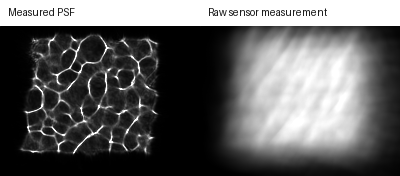

In [22]:
save_montage(
    [
        ('Measured PSF', sample.psf),
        ('Raw sensor measurement', sample.measurement),
    ],
    RESULT_DIR / 'inputs.png',
    columns=2,
)
Image.open(RESULT_DIR / 'inputs.png')

## Run FISTA Baseline

This is the Notebook 04 baseline. It gives us a reference reconstruction using data fidelity and nonnegativity, but without TV.

In [23]:
fista_result = fista(
    operator=operator,
    measurement=sample.measurement,
    iterations=250,
    record_every=25,
)

fista_prediction = operator.forward_padded(fista_result.padded_estimate)
fista_summary = {
    'relative_residual_l2': residual_relative_l2(sample.measurement, fista_prediction),
    'tv_value': total_variation_anisotropic(fista_result.padded_estimate),
    'max_reconstruction_value': float(fista_result.reconstruction.max()),
}
fista_summary

{'relative_residual_l2': 0.005005277747519048,
 'tv_value': 0.6175120495420463,
 'max_reconstruction_value': 0.00244115142636182}

## Run ADMM With Different TV Strengths

We compare:

- `tau = 0`: ADMM machinery with no TV penalty.
- `tau = 1e-9`: moderate TV for this normalized data scale.
- `tau = 3e-8`: stronger TV, more smoothing.

These `tau` values are small because the PSF and measurement have been L2-normalized. The important quantity in the soft-threshold step is `tau / mu2`.

In [24]:
admm_iterations = 10
record_every = 5
admm_parameters = {
    'mu1': 1e-6,
    'mu2': 1e-5,
    'mu3': 4e-5,
}

admm_experiments = [
    {'name': 'admm_no_tv', 'title': 'ADMM, no TV', 'tau': 0.0},
    {'name': 'admm_tv_moderate', 'title': 'ADMM, TV moderate', 'tau': 1e-9},
    {'name': 'admm_tv_strong', 'title': 'ADMM, TV strong', 'tau': 3e-8},
]

admm_results = {}
for experiment in admm_experiments:
    admm_results[experiment['name']] = admm_total_variation(
        operator=operator,
        measurement=sample.measurement,
        iterations=admm_iterations,
        record_every=record_every,
        tau=experiment['tau'],
        **admm_parameters,
    )

[(name, result.history[-1]) for name, result in admm_results.items()]

[('admm_no_tv',
  ADMMRecord(iteration=10, objective=0.0003203219620586186, data_fit=0.0003203219620586186, tv_value=0.6999513610403743, relative_residual_l2=0.025310944749598687, nonnegativity_violation_l2=0.0)),
 ('admm_tv_moderate',
  ADMMRecord(iteration=10, objective=0.00029045605686999724, data_fit=0.00029045545221456355, tv_value=0.6046554336945889, relative_residual_l2=0.02410209336197018, nonnegativity_violation_l2=0.0)),
 ('admm_tv_strong',
  ADMMRecord(iteration=10, objective=0.00019327142159993385, data_fit=0.00019325608719492882, tv_value=0.511146833501256, relative_residual_l2=0.019659912878491035, nonnegativity_violation_l2=0.0))]

## Quantitative Diagnostics

For real measured data, we still do not have ground truth. So we compare:

- data fit,
- relative residual,
- TV value,
- reconstruction intensity range.

Lower residual is not always visually better. TV deliberately trades some exact measurement fit for a more plausible image.

In [25]:
summary = {
    'data_info': data_info,
    'fista_baseline': fista_summary,
    'admm': {},
}

for experiment in admm_experiments:
    name = experiment['name']
    result = admm_results[name]
    record = result.history[-1]
    summary['admm'][name] = {
        'tau': experiment['tau'],
        'iterations': admm_iterations,
        'objective': record.objective,
        'data_fit': record.data_fit,
        'tv_value': record.tv_value,
        'relative_residual_l2': record.relative_residual_l2,
        'nonnegativity_violation_l2': record.nonnegativity_violation_l2,
        'max_reconstruction_value': float(result.reconstruction.max()),
    }

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))

{
  "data_info": {
    "psf_path": "E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\psf_sample.tif",
    "rawdata_path": "E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\rawdata_hand_sample.tif",
    "raw_shape_rows_cols": [
      1200,
      1600
    ],
    "processed_shape_rows_cols": [
      150,
      200
    ],
    "padded_shape": [
      512,
      512
    ],
    "background": 34.08,
    "imaging_adjoint_error": 2.056579521084895e-15,
    "finite_difference_adjoint_error": 2.432125730248415e-16
  },
  "fista_baseline": {
    "relative_residual_l2": 0.005005277747519048,
    "tv_value": 0.6175120495420463,
    "max_reconstruction_value": 0.00244115142636182
  },
  "admm": {
    "admm_no_tv": {
      "tau": 0.0,
      "iterations": 10,
      "objective": 0.0003203219620586186,
      "data_fit": 0.0003203219620586186,
      "tv_value": 0.6999513610403743,
      "relative_residual_l2": 0.025310944749598687,
 

## Visual Comparison

Look for the tradeoff:

- FISTA may fit the measurement well, but can leave structured artifacts.
- ADMM without TV shows what the split solver does before gradient sparsity is imposed.
- Moderate TV should reduce small oscillatory artifacts while keeping the hand edges.
- Strong TV can oversmooth or suppress fine details.

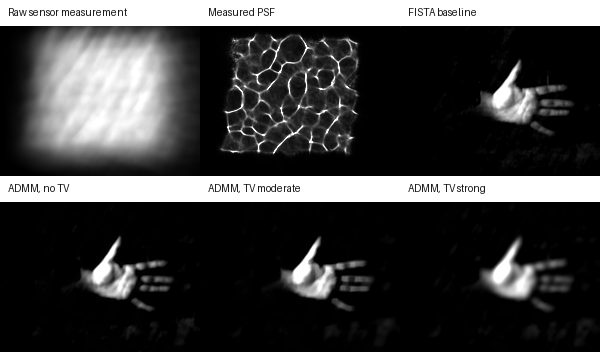

In [26]:
save_montage(
    [
        ('Raw sensor measurement', sample.measurement),
        ('Measured PSF', sample.psf),
        ('FISTA baseline', fista_result.reconstruction),
        ('ADMM, no TV', admm_results['admm_no_tv'].reconstruction),
        ('ADMM, TV moderate', admm_results['admm_tv_moderate'].reconstruction),
        ('ADMM, TV strong', admm_results['admm_tv_strong'].reconstruction),
    ],
    RESULT_DIR / 'reconstruction_comparison.png',
    columns=3,
)
Image.open(RESULT_DIR / 'reconstruction_comparison.png')

## ADMM Convergence

The objective includes the TV term, so objectives with different `tau` values are not directly comparable as pure data fits. The relative residual panel is useful for seeing how well each reconstruction explains the measurement.

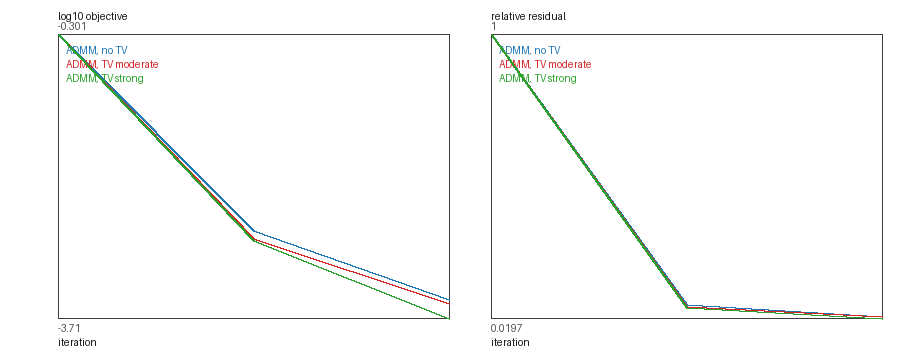

In [27]:
save_objective_residual_plot(
    [(experiment['title'], admm_results[experiment['name']].history) for experiment in admm_experiments],
    RESULT_DIR / 'admm_objective_residual.png',
)
Image.open(RESULT_DIR / 'admm_objective_residual.png')

## Interpretation

TV regularization is useful because it attacks a specific failure mode of inverse imaging: pixel-scale noise and ringing can have large total variation even when they help reduce the residual slightly.

The mathematical trick is the split variable `u = Psi v`. Once TV is isolated in `u`, the hard nonsmooth $\ell_1$ penalty turns into a simple soft-threshold step. The remaining large image update is quadratic and can be solved with FFTs.

This is why ADMM is a natural next step after FISTA:

- FISTA is conceptually simple for smooth objectives plus simple projections.
- ADMM is better suited when the objective combines several operators and nonsmooth priors.

Next task: tune ADMM more systematically with parameter sweeps for `tau`, `mu1`, `mu2`, and `mu3`, then compare runtime and quality against FISTA on the Waller sample and synthetic data.